In [4]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import glob


In [5]:
#Define output directory for the data
datadir = '/home/jovyan/SAMBBA_data/'

In [6]:
with open(datadir+'/man-ams_faam_20120929_r0_b746.na', "rb") as f:
    lines = f.readlines()  # Read the first 100 bytes
metadata_lines = lines[:46]  # Assume first 5 lines are metadata
header_line = metadata_lines[45].strip().split()  # Extract header names
# Decode if header contains byte strings
header_line = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line]
# Decode if metadata contains byte strings
metadata_lines = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines]

In [11]:
# Get all .nc files in the directory
file_paths = sorted(glob.glob(f'{datadir}/*746.nc'))

ds_psap = xr.open_dataset(file_paths[0])
ds_psap

<xarray.Dataset> Size: 289MB
Dimensions:        (data_point: 26520, sps32: 32, sps04: 4, sps01: 1, sps02: 2,
                    sps64: 64)
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/147)
    Time           (data_point) datetime64[ns] 212kB ...
    IAS_RVSM       (data_point, sps32) float32 3MB ...
    IAS_RVSM_FLAG  (data_point, sps32) float32 3MB ...
    TAS_RVSM       (data_point, sps32) float32 3MB ...
    TAS_RVSM_FLAG  (data_point, sps32) float32 3MB ...
    TAT_DI_R       (data_point, sps32) float32 3MB ...
    ...             ...
    TWC_TDEW       (data_point, sps64) float32 7MB ...
    TWC_TDEW_FLAG  (data_point, sps64) float32 7MB ...
    U_NOTURB       (data_point, sps01) float32 106kB ...
    U_NOTURB_FLAG  (data_point, sps01) float32 106kB ...
    V_NOTURB       (data_point, sps01) float32 106kB ...
    V_NOTURB_FLAG  (data_point, sps01) float32 106kB ...
Attributes: (12/23)
    conventions:         CF-1.0
    title:               Data from b746 on 29-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20121015
    TimeInterval:        09:22:42-16:44:41
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120929_...
    quality:             Flight Number: b746\nFlight Date: 29/09/2012\nCheck ...

In [12]:
data_lines = lines[46:]  # Actual data starts after metadata

In [13]:
# Print extracted metadata and headers
for i, line in enumerate(metadata_lines[:45], 1):  # Exclude header itself
    print(f"Metadata {i}: {line.strip()}")

print(f"Header: {header_line}")

Metadata 1: 46 1001
Metadata 2: Will Morgan, James Allan
Metadata 3: School of Earth, Atmospheric and Environmental Science, The University of Manchester
Metadata 4: AMS Aerosol Concentrations from FAAM BAE-146
Metadata 5: SAMBBA
Metadata 6: 1 1
Metadata 7: 2012 09 29 2014 04 04
Metadata 8: 0
Metadata 9: Time_start_UTC (seconds from 0000 UTC on start day)
Metadata 10: 12
Metadata 11: 1 1 1 1 1 1 1 1 1 1 1 1
Metadata 12: 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999
Metadata 13: Time_end_UTC (seconds from 0000 UTC on start day)
Metadata 14: Time_mid_UTC (seconds from 0000 UTC on start day)
Metadata 15: Sulphate
Metadata 16: Ammonium
Metadata 17: Organics
Metadata 18: Nitrate
Metadata 19: Chloride
Metadata 20: Sulphate uncertainty
Metadata 21: Ammonium uncertainty
Metadata 22: Organic uncertainty
Metadata 23: Nitrate uncertainty
Metadata 24: Chloride uncertainty
Metadata 25: 16
Metadata 26: PI_CONTACT_INFO: Centre for Atmospheric Science,

In [14]:
# Parse data into a NumPy array
data_array = np.array([line.strip().split() for line in data_lines], dtype=float)

# Define dimensions (assuming first column is time and others are variables)
dims = ("time", "variable")  # Modify as needed
time_coords = np.arange(data_array.shape[0])  # Placeholder for time index

# Convert to xarray Dataset with headers as variable names
ds = xr.Dataset(
    {name: ("time", data_array[:, i]) for i, name in enumerate(header_line)},
    coords={"time": time_coords},
    attrs={"Metadata": "\n".join(metadata_lines[:45])}  # Store metadata as an attribute
)

ds

<xarray.Dataset> Size: 257kB
Dimensions:          (time: 2297)
Coordinates:
  * time             (time) int64 18kB 0 1 2 3 4 5 ... 2292 2293 2294 2295 2296
Data variables: (12/13)
    Time_start_UTC   (time) float64 18kB 4.311e+04 4.314e+04 ... 5.997e+04
    Time_end_UTC     (time) float64 18kB 4.314e+04 4.317e+04 ... 5.998e+04
    Time_mid_UTC     (time) float64 18kB 4.312e+04 4.316e+04 ... 5.997e+04
    SO4              (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.1453 0.1977
    NH4              (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.07279 0.0649
    ORG              (time) float64 18kB 1e+07 1e+07 1e+07 ... 2.248 1.959 2.106
    ...               ...
    Chl              (time) float64 18kB 1e+07 1e+07 ... -0.001078 -0.000271
    SO4_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.01538 0.01561
    NH4_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.03741 0.03713
    ORG_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.05868 0.05833
    NO3_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.009552 0.009425
    Chl_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.005893 0.005934
Attributes:
    Metadata:  46 1001\nWill Morgan, James Allan\nSchool of Earth, Atmospheri...

In [16]:
def convert_time_to_datetime(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y %m %d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf

# Example usage
start_date = "2012 09 29"  # Example start date

# Convert time
ds0 = convert_time_to_datetime(ds, start_date)

# Print updated dataset with datetime coordinate
#ds0


In [17]:
# Filter out invalid SO4 values (9999999)
valid_SO4_mask = ds0["SO4"] != 9999999
filtered_ds_SO4 = ds0.where(valid_SO4_mask, drop=True)

# Filter out invalid NH4 values (9999999)
valid_NH4_mask = ds0["NH4"] != 9999999
filtered_ds_NH4 = ds0.where(valid_NH4_mask, drop=True)

# Filter out invalid ORG values (9999999)
valid_ORG_mask = ds0["ORG"] != 9999999
filtered_ds_ORG = ds0.where(valid_ORG_mask, drop=True)

# Filter out invalid NO3 values (9999999)
valid_NO3_mask = ds0["NO3"] != 9999999
filtered_ds_NO3 = ds0.where(valid_NO3_mask, drop=True)


# Filter out invalid Chl values (9999999)
valid_Chl_mask = ds0["Chl"] != 9999999
filtered_ds_Chl = ds0.where(valid_Chl_mask, drop=True)

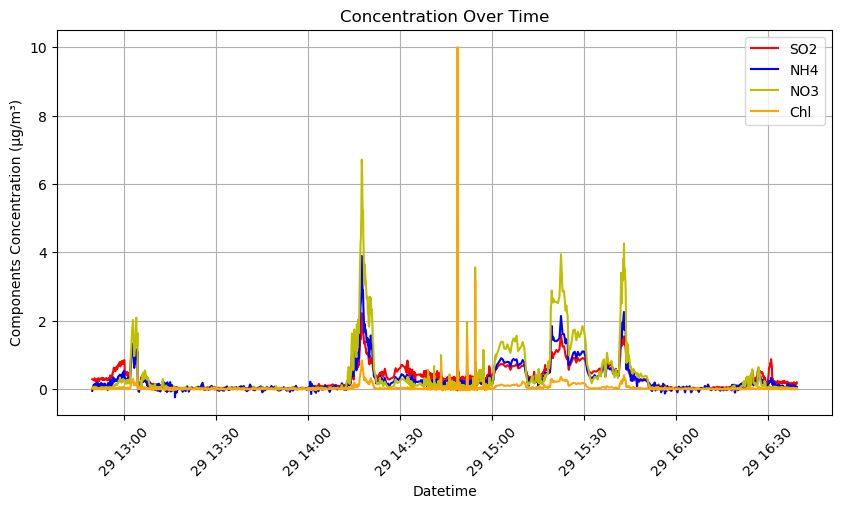

In [18]:
# Plot SO4 vs. datetime
plt.figure(figsize=(10, 5))
plt.plot(filtered_ds_SO4.datetime, filtered_ds_SO4["SO4"], label="SO2", color="r")
plt.plot(filtered_ds_NH4.datetime, filtered_ds_NH4["NH4"], label="NH4", color="b")
#plt.plot(filtered_ds_ORG.datetime, filtered_ds_ORG["ORG"], label="ORG", color="g")
plt.plot(filtered_ds_NO3.datetime, filtered_ds_NO3["NO3"], label="NO3", color="y")
plt.plot(filtered_ds_Chl.datetime, filtered_ds_Chl["Chl"], label="Chl", color="orange")

# Formatting
plt.xlabel("Datetime")
plt.ylabel("Components Concentration (µg/m³)")
plt.title("Concentration Over Time")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

# Show plot
plt.show()

In [26]:
ds_psap

<xarray.Dataset> Size: 289MB
Dimensions:        (data_point: 26520, sps32: 32, sps04: 4, sps01: 1, sps02: 2,
                    sps64: 64)
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/147)
    Time           (data_point) datetime64[ns] 212kB 2012-09-29T09:22:42 ... ...
    IAS_RVSM       (data_point, sps32) float32 3MB ...
    IAS_RVSM_FLAG  (data_point, sps32) float32 3MB ...
    TAS_RVSM       (data_point, sps32) float32 3MB ...
    TAS_RVSM_FLAG  (data_point, sps32) float32 3MB ...
    TAT_DI_R       (data_point, sps32) float32 3MB ...
    ...             ...
    TWC_TDEW       (data_point, sps64) float32 7MB ...
    TWC_TDEW_FLAG  (data_point, sps64) float32 7MB ...
    U_NOTURB       (data_point, sps01) float32 106kB ...
    U_NOTURB_FLAG  (data_point, sps01) float32 106kB ...
    V_NOTURB       (data_point, sps01) float32 106kB ...
    V_NOTURB_FLAG  (data_point, sps01) float32 106kB ...
Attributes: (12/23)
    conventions:         CF-1.0
    title:               Data from b746 on 29-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20121015
    TimeInterval:        09:22:42-16:44:41
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120929_...
    quality:             Flight Number: b746\nFlight Date: 29/09/2012\nCheck ...

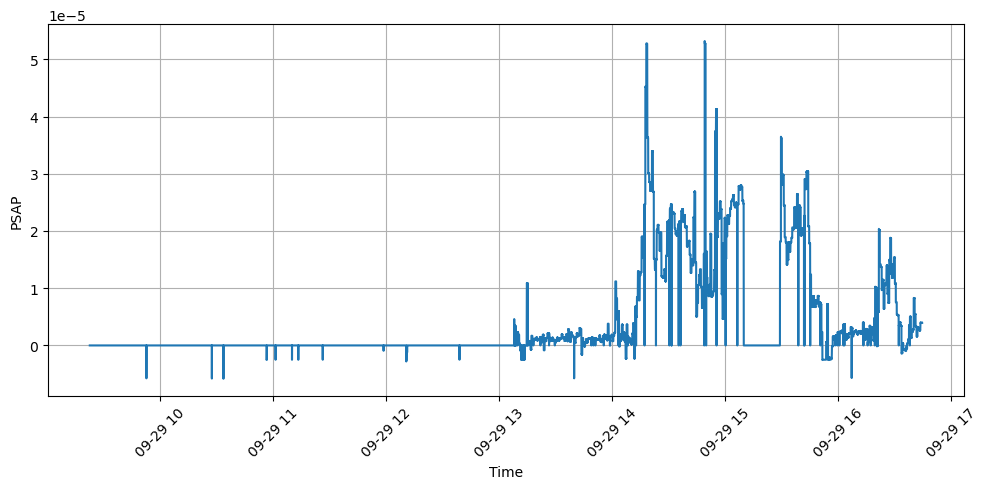

In [27]:
psap_lin = ds_psap['PSAP_LIN'].values
time_psap = ds_psap['Time'].values
psap_log = ds_psap['PSAP_LOG'].values
# Step 1: Extract the PSAP_LOG and time data
#PSAP = concatenated_psap_lin.flatten()  # Flatten the PSAP_LOG array
#time_values = pd.to_datetime(time)  # Flatten the time values and convert to pandas datetime

# Step 2: Create a pandas DataFrame for easier resampling
#df = pd.DataFrame({
#    'PSAP': psap_lin,
#    'Time': time_values
#})

# Step 3: Set 'Time' as the index
#df.set_index('Time', inplace=True)

# Step 4: Resample the data to 5-minute intervals (adjust '5T' to '1T' or '10T' for 1 or 10 minutes)
#resampled_df = df.resample('5min').mean()  # Use '5T' for 5-minute intervals. Can change to '1T' or '10T'

# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(ds_psap['Time'], ds_psap['PSAP_LIN'])

plt.xlabel('Time')
plt.ylabel('PSAP')
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

In [49]:
ds_psap

<xarray.Dataset> Size: 289MB
Dimensions:        (data_point: 26520, sps32: 32, sps04: 4, sps01: 1, sps02: 2,
                    sps64: 64)
Coordinates:
    Time           (data_point) datetime64[ns] 212kB 2012-09-29T09:22:42 ... ...
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/146)
    IAS_RVSM       (data_point, sps32) float32 3MB ...
    IAS_RVSM_FLAG  (data_point, sps32) float32 3MB ...
    TAS_RVSM       (data_point, sps32) float32 3MB ...
    TAS_RVSM_FLAG  (data_point, sps32) float32 3MB ...
    TAT_DI_R       (data_point, sps32) float32 3MB ...
    TAT_DI_R_FLAG  (data_point, sps32) float32 3MB ...
    ...             ...
    TWC_TDEW       (data_point, sps64) float32 7MB ...
    TWC_TDEW_FLAG  (data_point, sps64) float32 7MB ...
    U_NOTURB       (data_point, sps01) float32 106kB ...
    U_NOTURB_FLAG  (data_point, sps01) float32 106kB ...
    V_NOTURB       (data_point, sps01) float32 106kB ...
    V_NOTURB_FLAG  (data_point, sps01) float32 106kB ...
Attributes: (12/23)
    conventions:         CF-1.0
    title:               Data from b746 on 29-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20121015
    TimeInterval:        09:22:42-16:44:41
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120929_...
    quality:             Flight Number: b746\nFlight Date: 29/09/2012\nCheck ...

In [54]:
filtered_time = filtered_ds_SO4.datetime.values  # Reference timestamps
psap_time = ds_psap["Time"].values  # Original timestamps from new dataset


common_times = np.intersect1d(filtered_time, psap_time)

# Create a boolean mask as an Xarray DataArray
mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])

# Apply the mask to filter ds_psap
ds_psap_matched = ds_psap.where(mask, drop=True)

ds_psap_matched

<xarray.Dataset> Size: 20MB
Dimensions:        (data_point: 1877, sps32: 32, sps04: 4, sps01: 1, sps02: 2,
                    sps64: 64)
Coordinates:
    Time           (data_point) datetime64[ns] 15kB 2012-09-29T12:49:30 ... 2...
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/146)
    IAS_RVSM       (data_point, sps32) float32 240kB 3.926 3.926 ... 4.436 4.436
    IAS_RVSM_FLAG  (data_point, sps32) float32 240kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TAS_RVSM       (data_point, sps32) float32 240kB 4.039 4.039 ... 4.594 4.594
    TAS_RVSM_FLAG  (data_point, sps32) float32 240kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    TAT_DI_R       (data_point, sps32) float32 240kB 302.6 302.6 ... 305.9 305.9
    TAT_DI_R_FLAG  (data_point, sps32) float32 240kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
    ...             ...
    TWC_TDEW       (data_point, sps64) float32 481kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TWC_TDEW_FLAG  (data_point, sps64) float32 481kB 3.0 3.0 3.0 ... 3.0 3.0 3.0
    U_NOTURB       (data_point, sps01) float32 8kB 0.2391 -0.08128 ... 2.189
    U_NOTURB_FLAG  (data_point, sps01) float32 8kB nan nan nan ... nan nan nan
    V_NOTURB       (data_point, sps01) float32 8kB 0.04386 -2.989 ... 0.1749
    V_NOTURB_FLAG  (data_point, sps01) float32 8kB nan nan nan ... nan nan nan
Attributes: (12/23)
    conventions:         CF-1.0
    title:               Data from b746 on 29-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20121015
    TimeInterval:        09:22:42-16:44:41
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120929_...
    quality:             Flight Number: b746\nFlight Date: 29/09/2012\nCheck ...

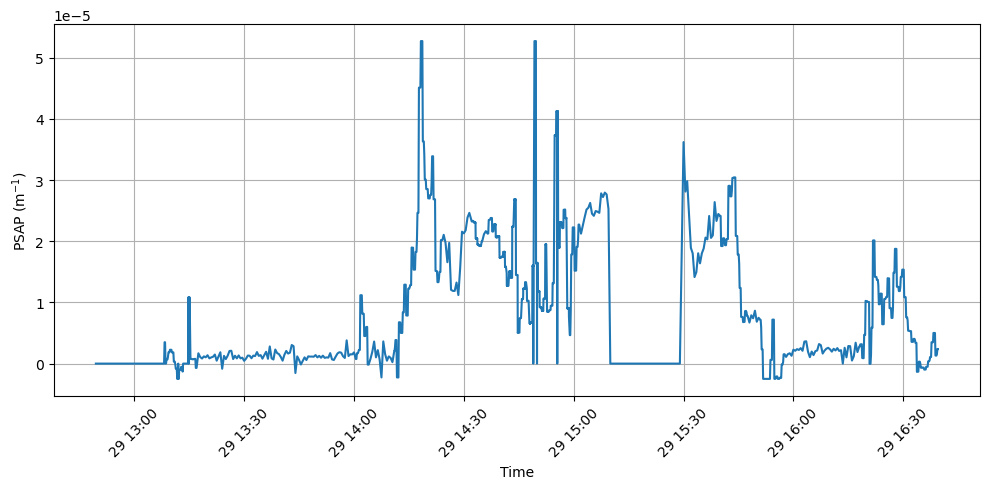

In [58]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(ds_psap_matched['Time'], ds_psap_matched['PSAP_LIN'])

plt.xlabel('Time')
plt.ylabel(r'Absortion Coefficient ($\mathrm{m^{-1}}$)')
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

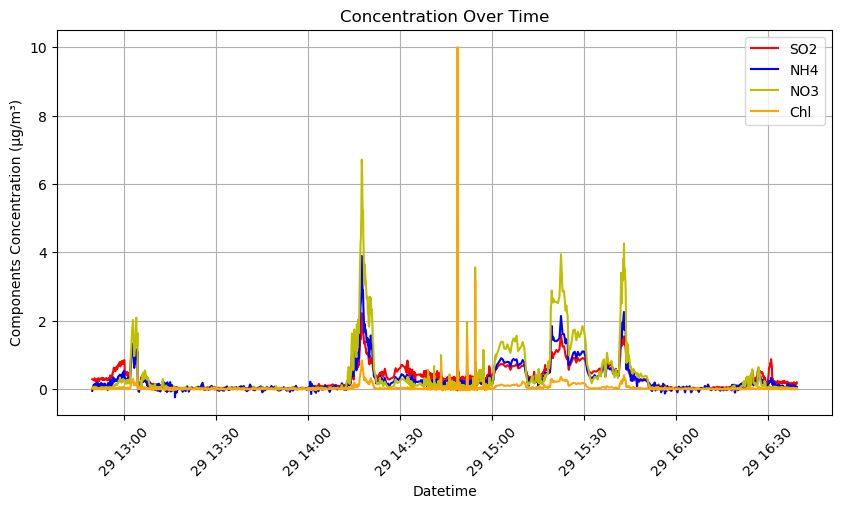

In [57]:
# Plot SO4 vs. datetime
plt.figure(figsize=(10, 5))
plt.plot(common_times, filtered_ds_SO4["SO4"], label="SO2", color="r")
plt.plot(common_times, filtered_ds_NH4["NH4"], label="NH4", color="b")
#plt.plot(common_times, filtered_ds_ORG["ORG"], label="ORG", color="g")
plt.plot(common_times, filtered_ds_NO3["NO3"], label="NO3", color="y")
plt.plot(common_times, filtered_ds_Chl["Chl"], label="Chl", color="orange")

# Formatting
plt.xlabel("Datetime")
plt.ylabel("Components Concentration (µg/m³)")
plt.title("Concentration Over Time")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

# Show plot
plt.show()

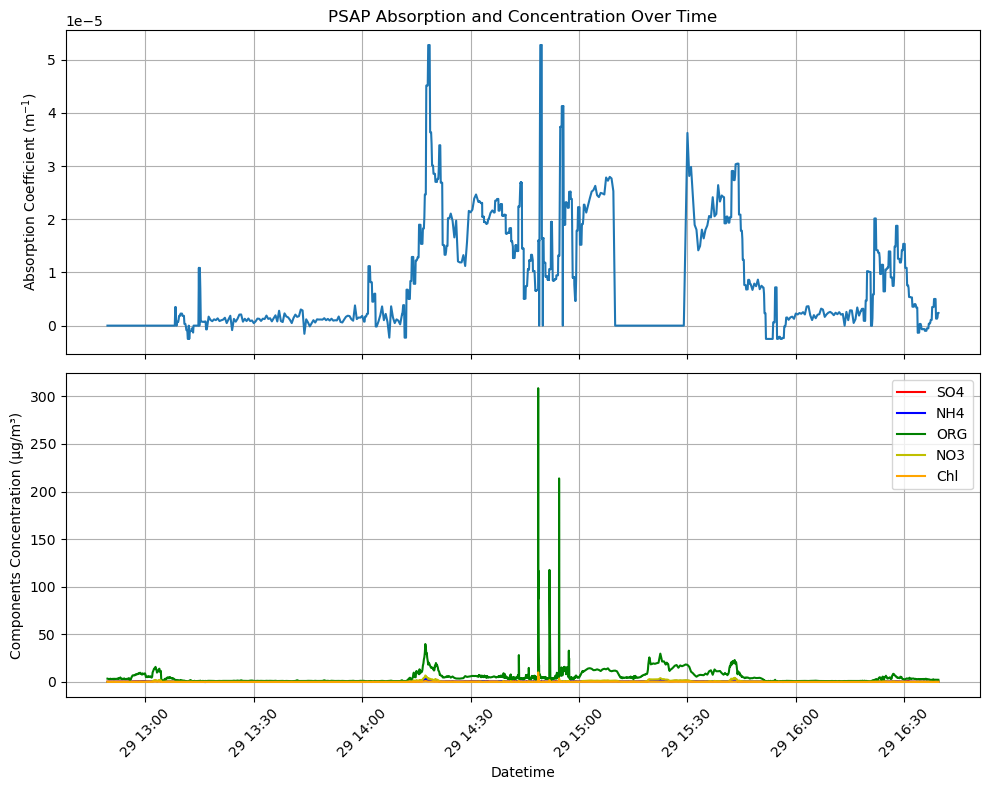

In [64]:
# Create a figure with two subplots sharing the x-axis
fig, ax1 = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- First Plot: PSAP_LOG Values ---
ax1[0].plot(ds_psap_matched['Time'], ds_psap_matched['PSAP_LIN'])
ax1[0].set_ylabel(r'Absorption Coefficient ($\mathrm{m^{-1}}$)')
ax1[0].grid()
ax1[0].set_title("PSAP Absorption and Concentration Over Time")

# --- Second Plot: Concentrations ---
ax1[1].plot(common_times, filtered_ds_SO4["SO4"], label="SO4", color="r")
ax1[1].plot(common_times, filtered_ds_NH4["NH4"], label="NH4", color="b")
ax1[1].plot(common_times, filtered_ds_ORG["ORG"], label="ORG", color="g")
#plt.plot(common_times, filtered_ds_ORG["ORG"], label="ORG", color="g")
ax1[1].plot(common_times, filtered_ds_NO3["NO3"], label="NO3", color="y")
ax1[1].plot(common_times, filtered_ds_Chl["Chl"], label="Chl", color="orange")

ax1[1].set_xlabel("Datetime")
ax1[1].set_ylabel("Components Concentration (µg/m³)")
ax1[1].grid()
ax1[1].legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the figure
plt.show()
